In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
col_transform = lambda c: c/2+0.5

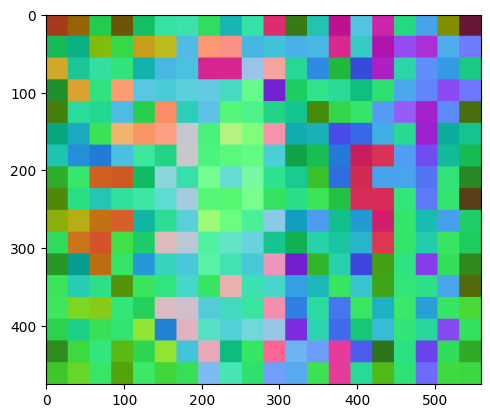

In [21]:
f = np.load('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_patch_features_dim3/000080_f.npy')
s = np.load('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_patch_features_dim3/000080_s.npy')
s = np.array(s, dtype=np.int32)
lf = f[s]
plt.imshow(col_transform(lf[0]))
plt.show()

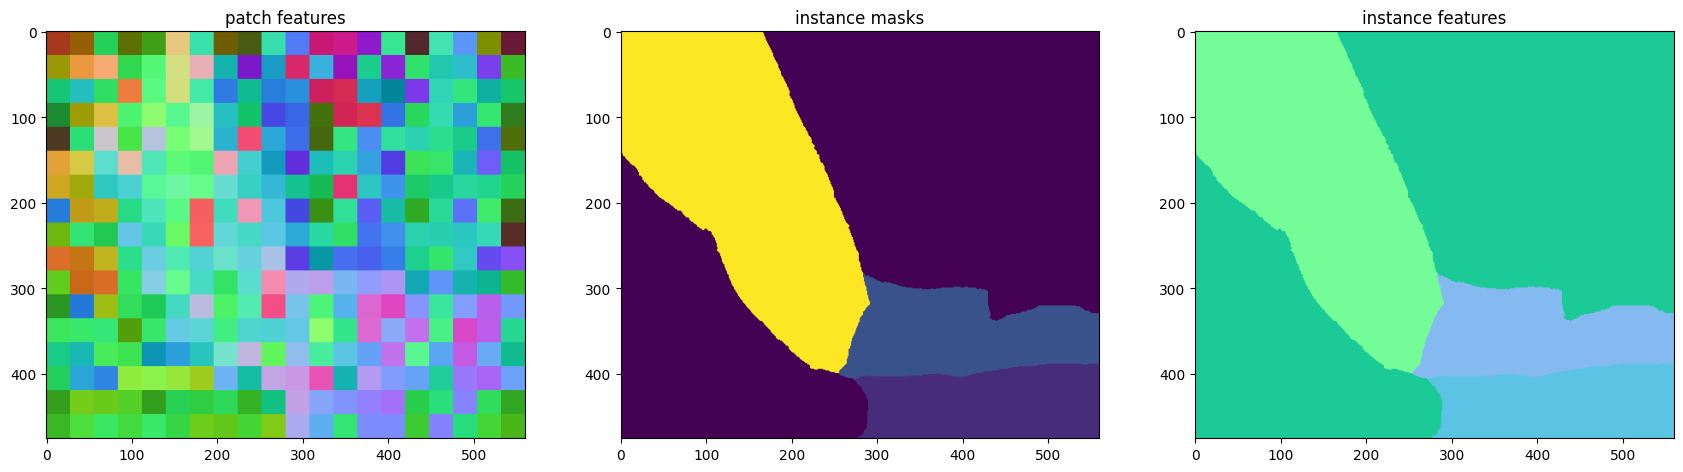

In [6]:
vid, clip, frame = 1, 80, 1
m = np.load(f'data/cholecseg8k/preprocessed_ssg/video{vid:02}/video{vid:02}_{clip:05}/instance_masks/frame_{frame:06}.npy')
pf = np.load(f'data/cholecseg8k/preprocessed_ssg/video{vid:02}/video{vid:02}_{clip:05}/qwen_patch_features_dim3/{frame:06}_f.npy')
ps = np.load(f'data/cholecseg8k/preprocessed_ssg/video{vid:02}/video{vid:02}_{clip:05}/qwen_patch_features_dim3/{frame:06}_s.npy')[0]
ps = np.array(ps, dtype=np.int32)
plf = pf[ps]
inf = np.load(f'data/cholecseg8k/preprocessed_ssg/video{vid:02}/video{vid:02}_{clip:05}/qwen_instance_features_dim3/{frame:06}_f.npy')
ins = np.load(f'data/cholecseg8k/preprocessed_ssg/video{vid:02}/video{vid:02}_{clip:05}/qwen_instance_features_dim3/{frame:06}_s.npy')[0]
ins = np.array(ins, dtype=np.int32)
inlf = inf[ins]
fig, axs = plt.subplots(1, 3, figsize=(21, 9))
axs[0].imshow(col_transform(plf))
axs[0].set_title('patch features')
axs[1].imshow(m)
axs[1].set_title('instance masks')
axs[2].imshow(col_transform(inlf))
axs[2].set_title('instance features')

plt.show()

In [6]:
cf = np.load(f'data/cholecseg8k/preprocessed_ssg/video{vid:02}/video{vid:02}_{clip:05}/qwen_cat_features_dim3/{frame:06}_f.npy')
cs = np.load(f'data/cholecseg8k/preprocessed_ssg/video{vid:02}/video{vid:02}_{clip:05}/qwen_cat_features_dim3/{frame:06}_s.npy')[0]

In [14]:
clf = cf[cs]

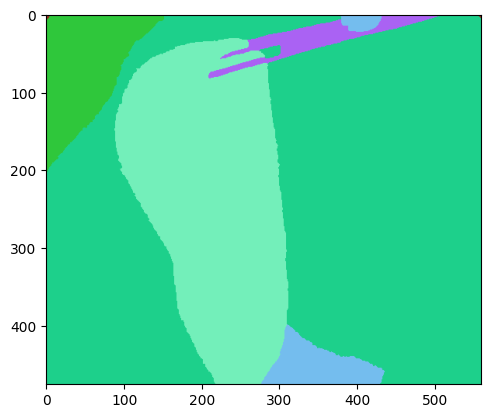

In [18]:
plt.imshow(col_transform(clf[:, :, 3:]))
plt.show()

In [60]:
latent_mean_f = np.stack([
    np.mean(plf.reshape(-1, 3)[ins.reshape(-1) == mask_id], axis=0)
    for mask_id in np.unique(ins)
])
latent_mean_f /= np.linalg.norm(latent_mean_f, axis=-1, keepdims=True)

In [ ]:
(np.unique(ins) == np.arange(np.unique(ins).max()+1)).all()

works
